In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [2]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [3]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.zeros((16, 1000)).to("cuda")
for i in range(16):
    labels[i, i] = 1

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde.EDMSDE().to("cuda")
# sde_ = sde.VarianceExplodingEDMSDE(sigma_min, sigma_max).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")
rsde.ode = False

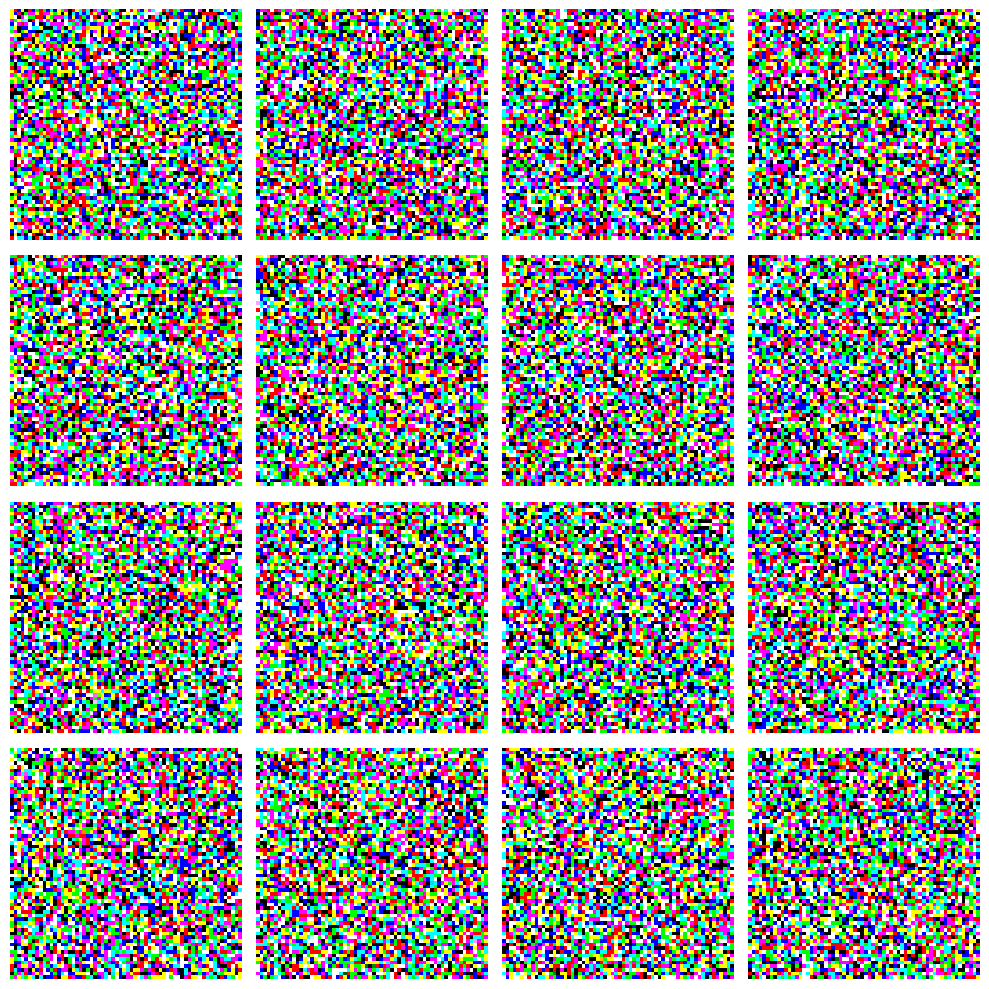

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [8]:
n_steps = 177
rho = 7
# From EDM2 code
step_indices = torch.arange(n_steps)
sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])
# discretisation = torch.linspace(1, 0, n_steps)

In [9]:
em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

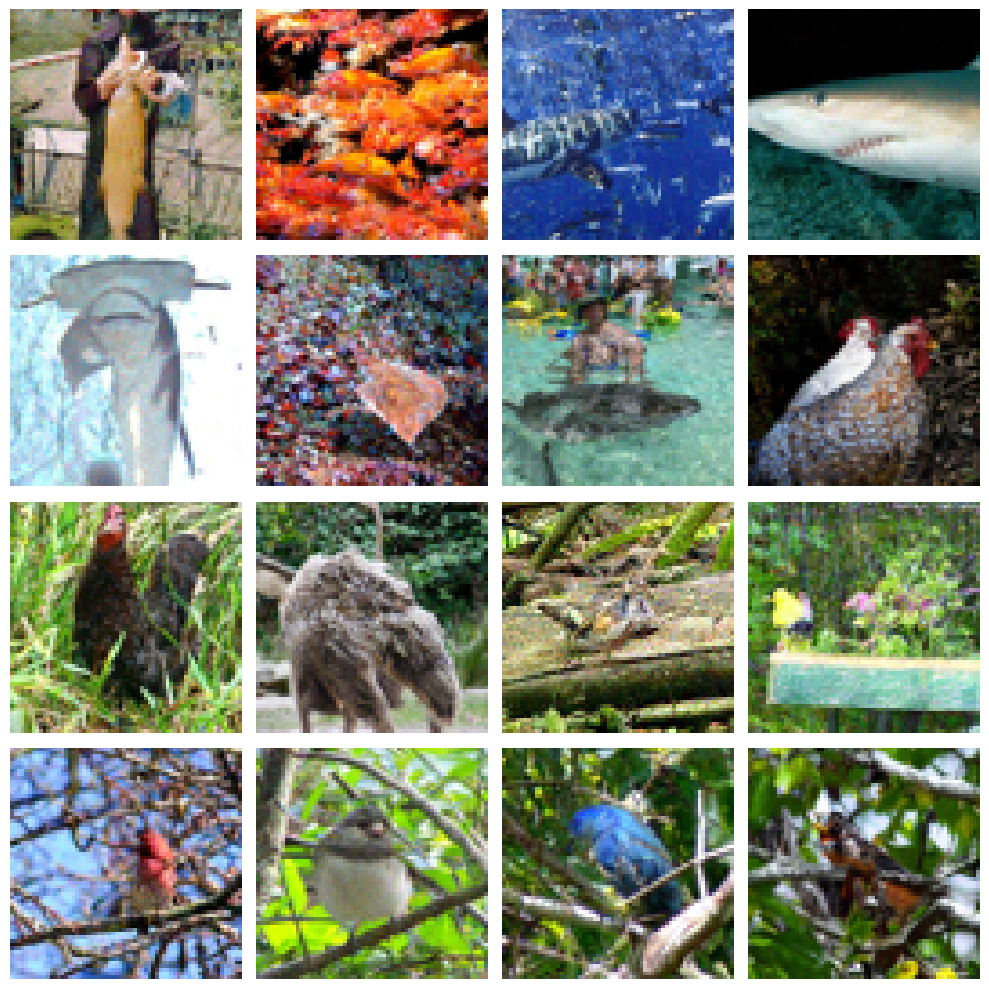

In [10]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [11]:
sigmas = []
def pi_callback(x, t):    
    print(f"sigma = {torch.mean(t)}")
    sigmas.append(torch.mean(t))

In [12]:
sigmas = []

rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.3,
    tau_r=0.9,
    alpha=0.9,
    h_start=3,
    max_h=100,
    max_decrease=0.2,
    max_increase=5,
    timeout=1000,
    interval=(80, 0.002),
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 77.0
sigma = 72.94762420654297
sigma = 69.04389953613281
sigma = 65.11629486083984
sigma = 61.307891845703125
sigma = 57.646785736083984
sigma = 54.15746307373047
sigma = 50.84657287597656
sigma = 47.719276428222656
sigma = 44.771724700927734
sigma = 41.99763488769531
sigma = 39.38936233520508
sigma = 36.938568115234375
sigma = 34.63727951049805
sigma = 32.4801139831543
sigma = 30.454896926879883
sigma = 28.552946090698242
sigma = 26.771202087402344
sigma = 25.098979949951172
sigma = 23.530044555664062
sigma = 22.05887794494629
sigma = 20.67803192138672
sigma = 19.384357452392578
sigma = 18.170230865478516
sigma = 17.03201675415039
sigma = 15.964364051818848
sigma = 14.962467193603516
sigma = 14.022958755493164
sigma = 13.143020629882812
sigma = 12.317986488342285
sigma = 11.543092727661133
sigma = 10.817037582397461
sigma = 10.135235786437988
sigma = 9.495664596557617
sigma = 8.895061492919922
sigma = 8.331743240356445
sigma = 7.803310871124268
sigma = 7.306807518005371
sigma 

In [13]:
rsde.nfe / 16

181.25

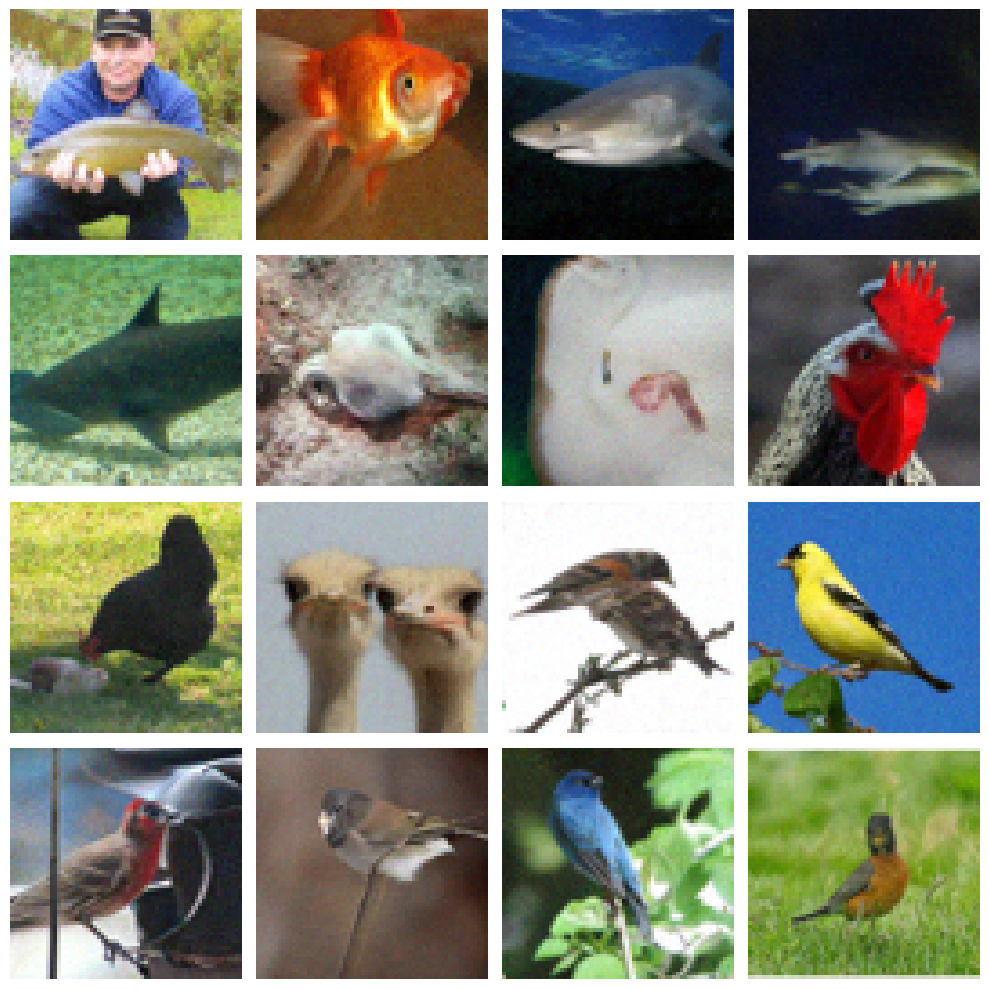

In [14]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

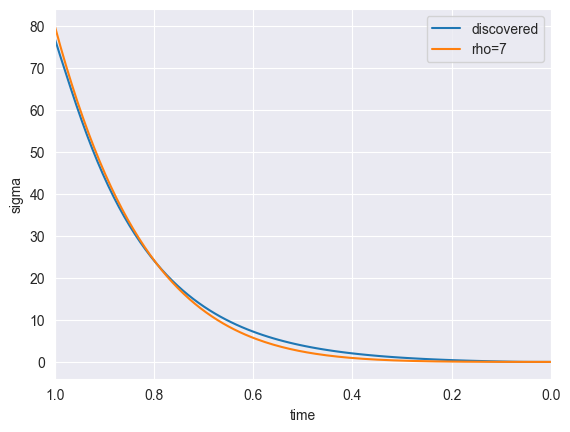

In [15]:
plt.plot(torch.linspace(1, 0, len(sigmas)), [sigma.cpu() for sigma in sigmas], label="discovered")
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")